In [ ]:
import pandas as pd
import numpy as np 
from pathlib import Path
data_path=Path(r'C:\Users\vinee\ML_Project\data\raw\electricity_consumption_raw.csv')
df=pd.read_csv(data_path)

In [5]:
meta_col=['CONS_NO','FLAG']
date_col=[col for col in df.columns if col not in meta_col ]
print('dataset shape',df.shape)
print('consumption columns',len(date_col))

dataset shape (42372, 1036)
consumption columns 1034


### Missing values per consumer

In [7]:
con_data=df[date_col]
miss_p_csr= con_data.isnull().sum(axis=1)
miss_summ=pd.DataFrame({
    'CONS_NO':df['CONS_NO'],
    "FLAG":df['FLAG'],
    'Missing_days':miss_p_csr
})
miss_summ['missing_pct']=(miss_summ['Missing_days']/len(date_col)*100)
miss_summ.head(2)

,CONS_NO,FLAG,Missing_days,missing_pct
0,0387DD8A07E07FDA6271170F86AD9151,1,4,0.386847
1,01D6177B5D4FFE0CABA9EF17DAFC2B84,1,188,18.181818


#### FLAG wise missing values

In [8]:
miss_by_flag=(miss_summ.groupby('FLAG')['missing_pct'].agg(['count','mean','median','min','max']))
miss_by_flag

,count,mean,median,min,max
FLAG,,,,,
0,38757,25.096246,9.284333,0.096712,100.0
1,3615,31.468735,21.373308,0.096712,100.0


#### Missing distribution graph

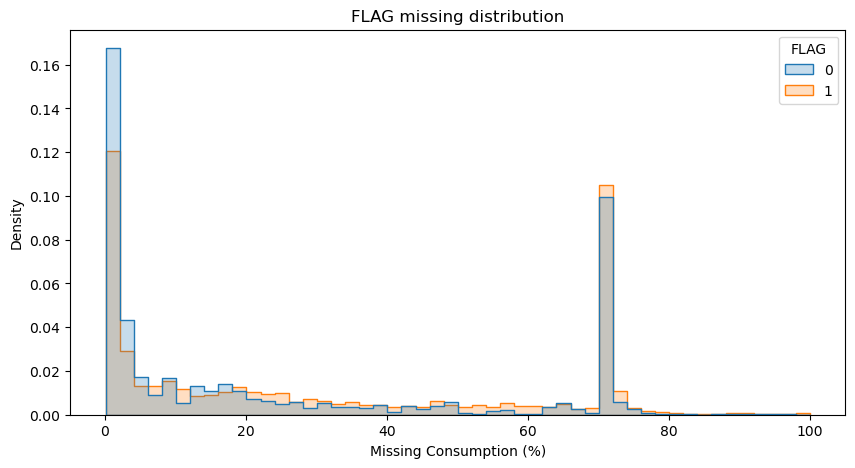

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,5))
sns.histplot(data=miss_summ,x='missing_pct',hue='FLAG',bins=50,element='step',stat='density',common_norm=False)
plt.xlabel('Missing Consumption (%)')
plt.ylabel("Density")
plt.title('FLAG missing distribution')
plt.show()

In [11]:
complete_miss=miss_summ[miss_summ['Missing_days']==len(date_col)]
print('100% missing consumption',len(complete_miss))
complete_miss['FLAG'].value_counts()

100% missing consumption 5


FLAG
1    3
0    2
Name: count, dtype: int64

#### High missingness consumers

In [14]:
high_miss=miss_summ[miss_summ['missing_pct']>=50]
print('consumer with 50% miss data',len(high_miss))
print('Flag distributionn')
print(high_miss['FLAG'].value_counts(normalize=True)*100)


consumer with 50% miss data 11187
Flag distributionn
FLAG
0    89.201752
1    10.798248
Name: proportion, dtype: float64
